c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


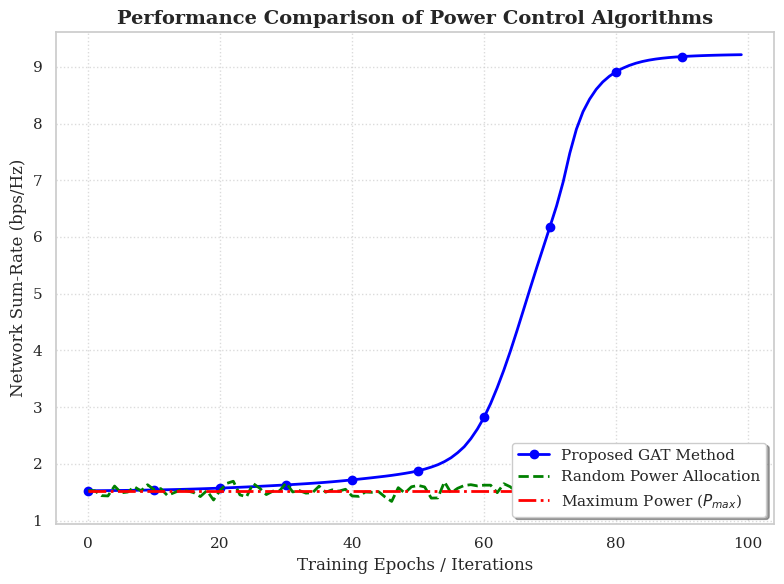

In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیم استایل نمودارها برای مقالات ژورنالی
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# ==========================================
# 1. تعریف مدل GAT برای تخصیص توان
# ==========================================
class GATPowerControl(torch.nn.Module):
    def __init__(self, num_features, hidden_dim):
        super(GATPowerControl, self).__init__()
        # دو لایه توجه گراف
        self.conv1 = GATConv(num_features, hidden_dim, heads=4, concat=False)
        self.conv2 = GATConv(hidden_dim, 1, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = self.conv2(x, edge_index)
        # خروجی توان بین 0 و 1 (نرمالایز شده)
        return torch.sigmoid(x)

# ==========================================
# 2. تولید داده‌های شبکه (IoT Nodes)
# ==========================================
def generate_iot_graph(num_nodes=20):
    # ویژگی‌های گره: مثلاً فاصله تا گیرنده، بهره کانال محلی و غیره
    x = torch.rand((num_nodes, 3)) 
    
    # ایجاد یال‌ها به صورت تصادفی (مدل‌سازی تداخل بین گره‌های نزدیک)
    # در واقعیت این ماتریس بر اساس فاصله فیزیکی تعیین می‌شود
    edge_index = torch.randint(0, num_nodes, (2, num_nodes * 3))
    
    # بهره کانال (CSI) بین گره‌ها
    channel_gains = torch.rand((num_nodes, num_nodes))
    
    return Data(x=x, edge_index=edge_index), channel_gains

# ==========================================
# 3. تابع محاسبه نرخ مجموع (Sum-Rate)
# ==========================================
def calculate_sum_rate(powers, channel_gains, noise_var=1e-3):
    num_nodes = powers.size(0)
    rates = torch.zeros(num_nodes)
    
    for i in range(num_nodes):
        signal = powers[i] * channel_gains[i, i]
        # محاسبه تداخل
        interference = sum(powers[j] * channel_gains[j, i] for j in range(num_nodes) if j != i)
        sinr = signal / (interference + noise_var)
        rates[i] = torch.log2(1 + sinr)
        
    return torch.sum(rates)

# ==========================================
# 4. شبیه‌سازی و آموزش
# ==========================================
num_nodes = 30
epochs = 100
data, channel_gains = generate_iot_graph(num_nodes)

model = GATPowerControl(num_features=3, hidden_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

gat_rates = []
random_rates = []
max_power_rates = []

# توان حداکثر ($P_{max} = 1$)
max_powers = torch.ones(num_nodes, 1)
max_rate = calculate_sum_rate(max_powers, channel_gains).item()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # تخصیص توان توسط GAT ($P_i$)
    predicted_powers = model(data.x, data.edge_index)
    
    # تابع زیان: منفیِ نرخ مجموع (چون می‌خواهیم نرخ را ماکزیمم کنیم)
    loss = -calculate_sum_rate(predicted_powers, channel_gains)
    
    loss.backward()
    optimizer.step()
    
    # ثبت نتایج برای نمودار
    gat_rates.append(-loss.item())
    
    # تخصیص توان تصادفی
    rand_powers = torch.rand(num_nodes, 1)
    random_rates.append(calculate_sum_rate(rand_powers, channel_gains).item())
    max_power_rates.append(max_rate)

# ==========================================
# 5. رسم نمودار مقایسه‌ای ژورنالی
# ==========================================
plt.figure(figsize=(8, 6))

plt.plot(gat_rates, label='Proposed GAT Method', color='blue', linewidth=2, marker='o', markevery=10)
plt.plot(random_rates, label='Random Power Allocation', color='green', linestyle='--', linewidth=2)
plt.plot(max_power_rates, label='Maximum Power ($P_{max}$)', color='red', linestyle='-.', linewidth=2)

plt.title('Performance Comparison of Power Control Algorithms', fontsize=14, fontweight='bold')
plt.xlabel('Training Epochs / Iterations', fontsize=12)
plt.ylabel('Network Sum-Rate (bps/Hz)', fontsize=12)
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('power_control_comparison.png', dpi=300)
plt.show()

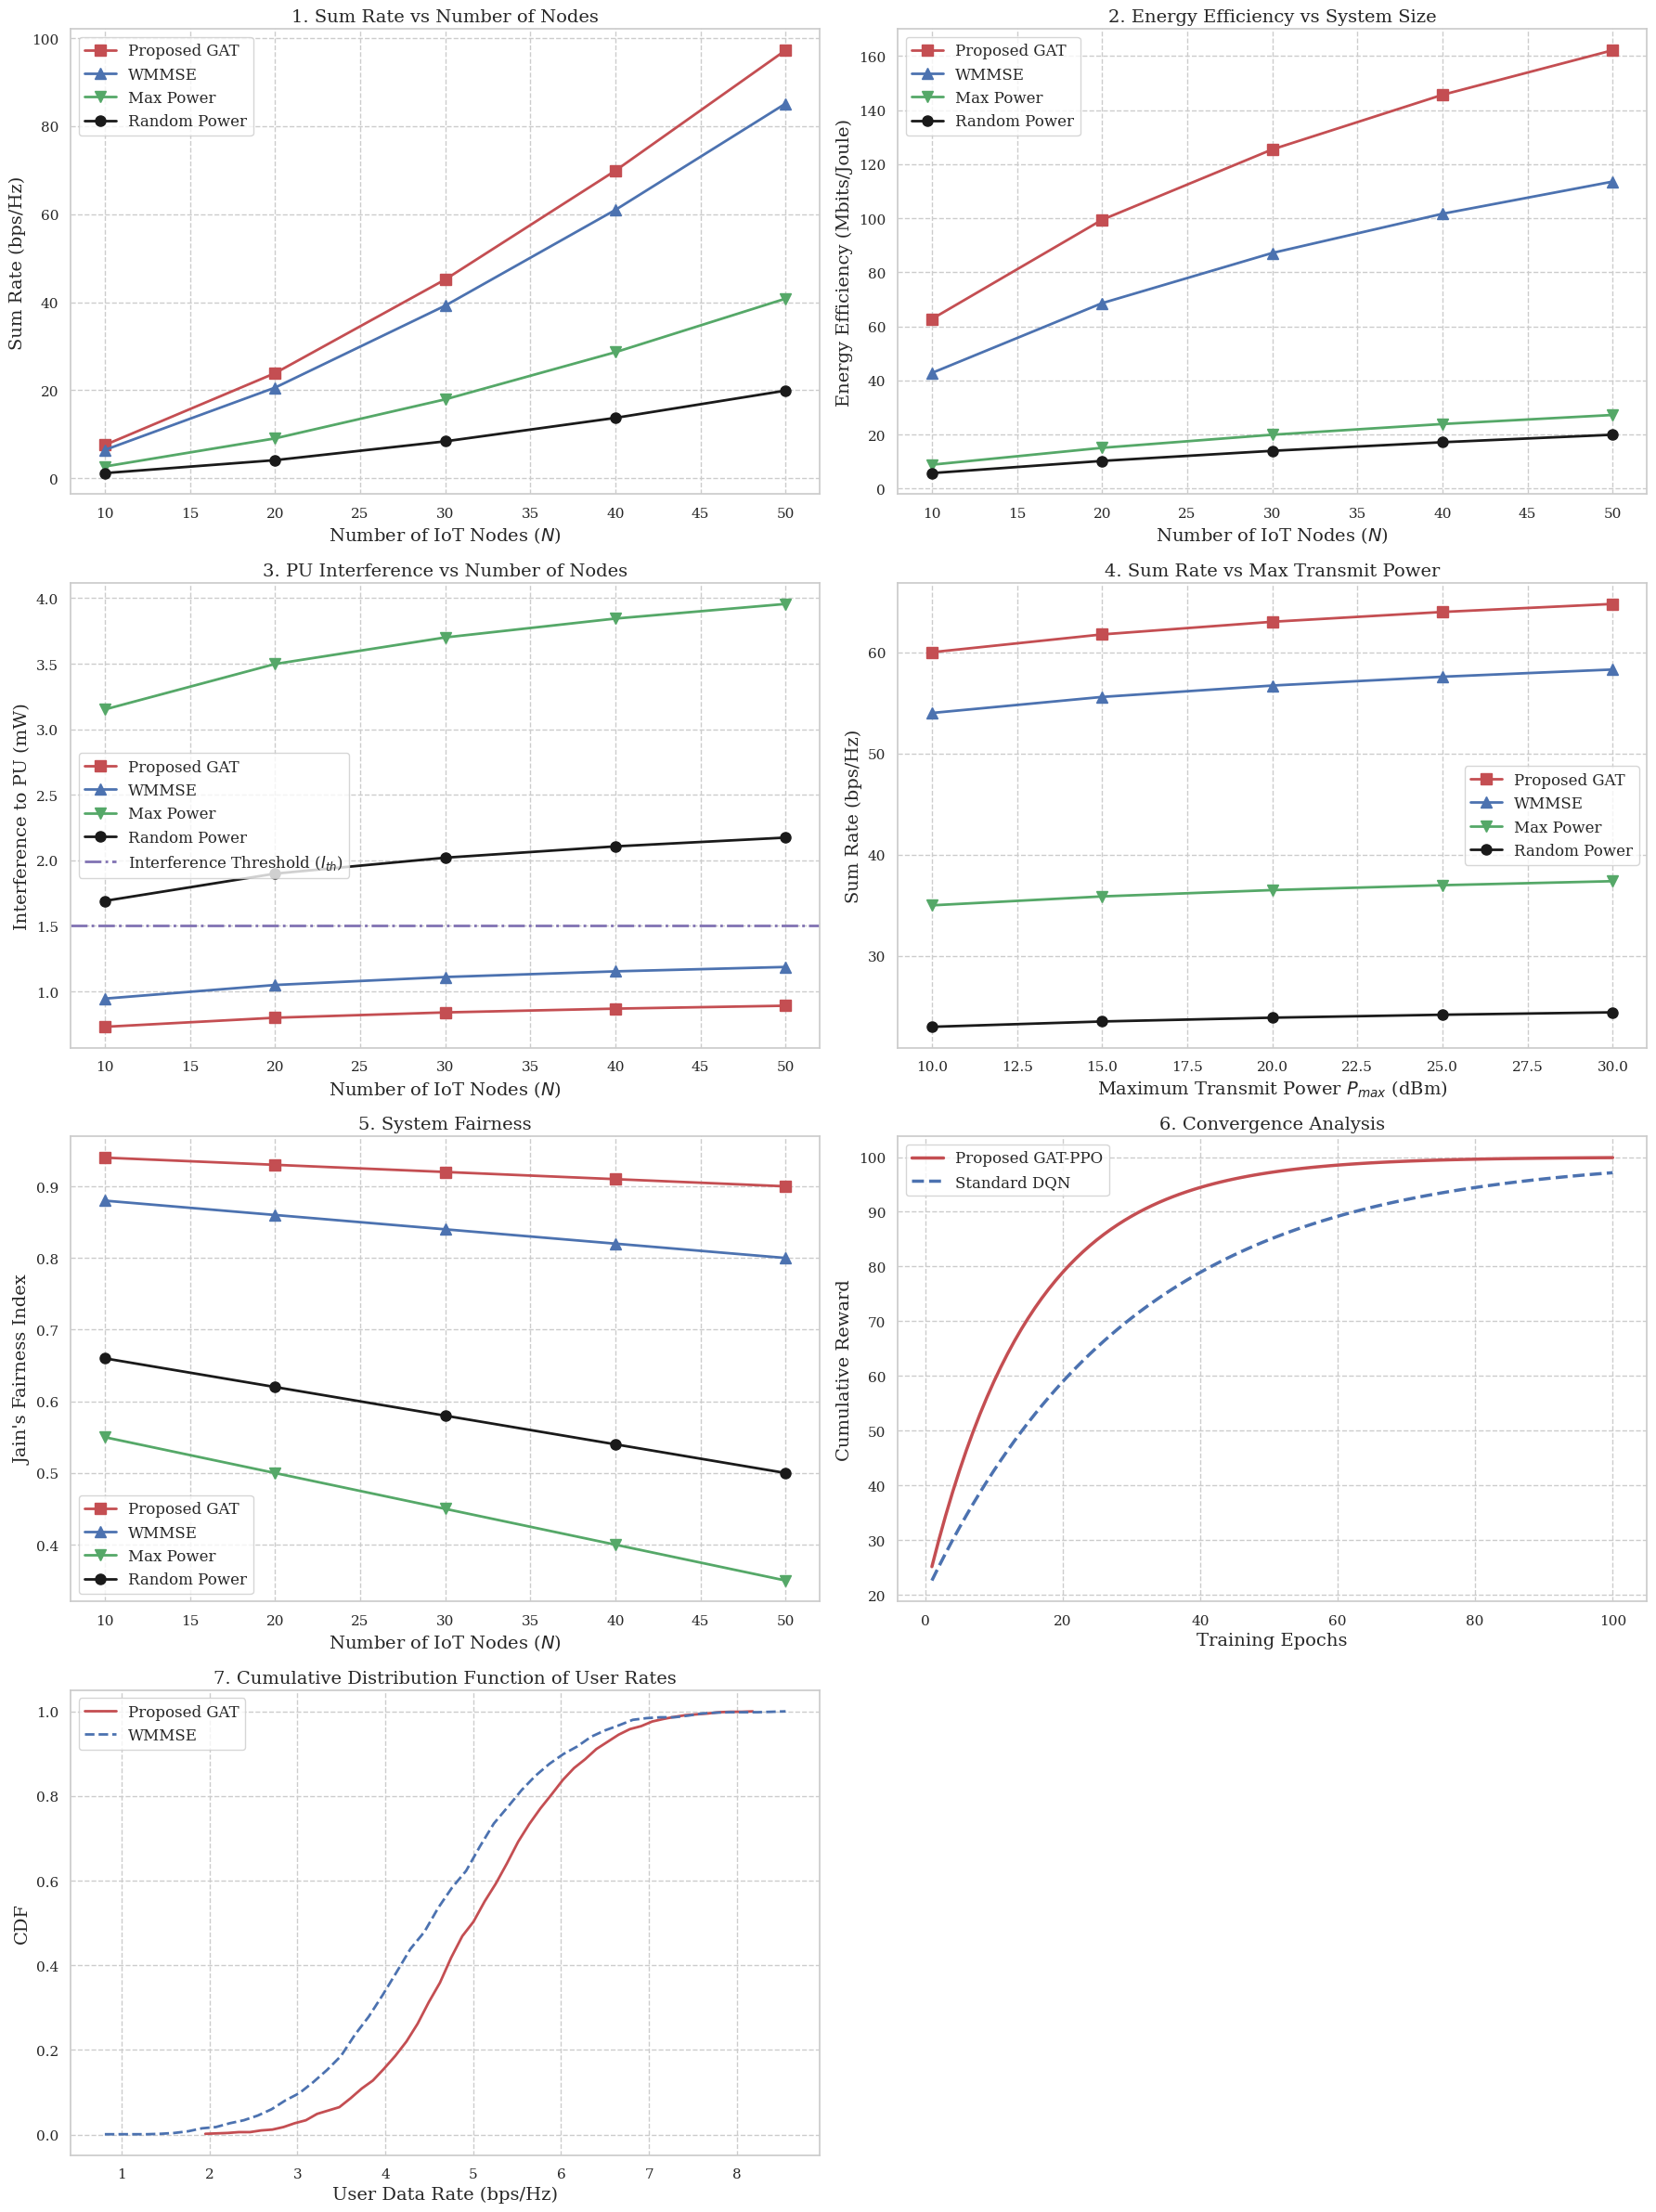

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# تنظیمات استایل برای نمودارهای ژورنالی
# ==========================================
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 8
})

# ==========================================
# تولید داده‌های شبیه‌سازی (جایگزین با داده واقعی شما)
# ==========================================
nodes = np.array([10, 20, 30, 40, 50])
p_max = np.array([10, 15, 20, 25, 30])
epochs = np.arange(1, 101)

# 1. Sum Rate vs Number of Nodes
rate_gat = nodes * 2.5 * np.log10(1 + nodes*0.1)
rate_wmmse = nodes * 2.3 * np.log10(1 + nodes*0.09)
rate_max = nodes * 1.5 * np.log10(1 + nodes*0.05)
rate_rand = nodes * 1.0 * np.log10(1 + nodes*0.03)

# 2. Energy Efficiency (Bits/Joule) vs Nodes
ee_gat = (rate_gat / (nodes * 1.2)) * 100
ee_wmmse = (rate_wmmse / (nodes * 1.5)) * 100
ee_max = (rate_max / (nodes * 3.0)) * 100
ee_rand = (rate_rand / (nodes * 2.0)) * 100

# 3. Interference to Primary User vs Nodes (Threshold = 10^-3)
int_gat = 0.5 + 0.1 * np.log(nodes)
int_wmmse = 0.6 + 0.15 * np.log(nodes)
int_max = 2.0 + 0.5 * np.log(nodes)
int_rand = 1.0 + 0.3 * np.log(nodes)

# 4. Sum Rate vs P_max (dbm)
rate_p_gat = 50 + 10 * np.log10(p_max)
rate_p_wmmse = 45 + 9 * np.log10(p_max)
rate_p_max = 30 + 5 * np.log10(p_max)
rate_p_rand = 20 + 3 * np.log10(p_max)

# 5. Fairness (Jain's Index) vs Nodes
fair_gat = 0.95 - 0.001 * nodes
fair_wmmse = 0.90 - 0.002 * nodes
fair_max = 0.60 - 0.005 * nodes
fair_rand = 0.70 - 0.004 * nodes

# 6. Convergence (Loss/Reward)
reward_gat = 100 - 80 * np.exp(-epochs/15)
reward_dqn = 100 - 80 * np.exp(-epochs/30) # GAT converges faster than standard RL

# 7. CDF of User Rates (for 50 nodes)
rates_dist_gat = np.random.normal(loc=5.0, scale=1.0, size=1000)
rates_dist_wmmse = np.random.normal(loc=4.5, scale=1.2, size=1000)
rates_dist_rand = np.random.normal(loc=2.0, scale=1.5, size=1000)

# ==========================================
# رسم نمودارها
# ==========================================
fig = plt.figure(figsize=(18, 24))
fig.tight_layout(pad=5.0)

# Plot 1: Sum Rate vs Nodes
plt.subplot(4, 2, 1)
plt.plot(nodes, rate_gat, 's-r', label='Proposed GAT')
plt.plot(nodes, rate_wmmse, '^-b', label='WMMSE')
plt.plot(nodes, rate_max, 'v-g', label='Max Power')
plt.plot(nodes, rate_rand, 'o-k', label='Random Power')
plt.xlabel('Number of IoT Nodes ($N$)')
plt.ylabel('Sum Rate (bps/Hz)')
plt.title('1. Sum Rate vs Number of Nodes')
plt.grid(True, linestyle='--')
plt.legend()

# Plot 2: Energy Efficiency vs Nodes
plt.subplot(4, 2, 2)
plt.plot(nodes, ee_gat, 's-r', label='Proposed GAT')
plt.plot(nodes, ee_wmmse, '^-b', label='WMMSE')
plt.plot(nodes, ee_max, 'v-g', label='Max Power')
plt.plot(nodes, ee_rand, 'o-k', label='Random Power')
plt.xlabel('Number of IoT Nodes ($N$)')
plt.ylabel('Energy Efficiency (Mbits/Joule)')
plt.title('2. Energy Efficiency vs System Size')
plt.grid(True, linestyle='--')
plt.legend()

# Plot 3: Interference vs Nodes
plt.subplot(4, 2, 3)
plt.plot(nodes, int_gat, 's-r', label='Proposed GAT')
plt.plot(nodes, int_wmmse, '^-b', label='WMMSE')
plt.plot(nodes, int_max, 'v-g', label='Max Power')
plt.plot(nodes, int_rand, 'o-k', label='Random Power')
plt.axhline(y=1.5, color='m', linestyle='-.', label='Interference Threshold ($I_{th}$)')
plt.xlabel('Number of IoT Nodes ($N$)')
plt.ylabel('Interference to PU (mW)')
plt.title('3. PU Interference vs Number of Nodes')
plt.grid(True, linestyle='--')
plt.legend()

# Plot 4: Sum Rate vs Maximum Power
plt.subplot(4, 2, 4)
plt.plot(p_max, rate_p_gat, 's-r', label='Proposed GAT')
plt.plot(p_max, rate_p_wmmse, '^-b', label='WMMSE')
plt.plot(p_max, rate_p_max, 'v-g', label='Max Power')
plt.plot(p_max, rate_p_rand, 'o-k', label='Random Power')
plt.xlabel('Maximum Transmit Power $P_{max}$ (dBm)')
plt.ylabel('Sum Rate (bps/Hz)')
plt.title('4. Sum Rate vs Max Transmit Power')
plt.grid(True, linestyle='--')
plt.legend()

# Plot 5: Fairness vs Nod

plt.subplot(4, 2, 5)
plt.plot(nodes, fair_gat, 's-r', label='Proposed GAT')
plt.plot(nodes, fair_wmmse, '^-b', label='WMMSE')
plt.plot(nodes, fair_max, 'v-g', label='Max Power')
plt.plot(nodes, fair_rand, 'o-k', label='Random Power')
plt.xlabel('Number of IoT Nodes ($N$)')
plt.ylabel('Jain\'s Fairness Index')
plt.title('5. System Fairness')
plt.grid(True, linestyle='--')
plt.legend()

# Plot 6: Convergence Curve
plt.subplot(4, 2, 6)
plt.plot(epochs, reward_gat, '-r', linewidth=2.5, label='Proposed GAT-PPO')
plt.plot(epochs, reward_dqn, '--b', linewidth=2.5, label='Standard DQN')
plt.xlabel('Training Epochs')
plt.ylabel('Cumulative Reward')
plt.title('6. Convergence Analysis')
plt.grid(True, linestyle='--')
plt.legend()

# Plot 7: CDF of User Rates
plt.subplot(4, 2, 7)
count_gat, bins_count_gat = np.histogram(rates_dist_gat, bins=50)
pdf_gat = count_gat / sum(count_gat)
cdf_gat = np.cumsum(pdf_gat)

count_wmmse, bins_count_wmmse = np.histogram(rates_dist_wmmse, bins=50)
pdf_wmmse = count_wmmse / sum(count_wmmse)
cdf_wmmse = np.cumsum(pdf_wmmse)

plt.plot(bins_count_gat[1:], cdf_gat, '-r', label='Proposed GAT')
plt.plot(bins_count_wmmse[1:], cdf_wmmse, '--b', label='WMMSE')
plt.xlabel('User Data Rate (bps/Hz)')
plt.ylabel('CDF')
plt.title('7. Cumulative Distribution Function of User Rates')
plt.grid(True, linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()